In [16]:
# --- Imports ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
# --- Efficiency score functions ---
eps = 1e-12  # tiny epislon to avoid division by zero


def eff_mse(t, p, E=1.0):
	"""Efficiency based on plain MSE."""
	mse = np.mean((p - t) ** 2)
	return 1 / (mse * E)


def eff_entropy(t, p, E=1.0):
	"""Efficiency based on mutual entropy gain."""
	mse = np.mean((p - t) ** 2)
	var_prior = np.var(t)
	info_gain = 0.5 * np.log2(var_prior / (mse + eps))
	return info_gain / E


def eff_mse_rel(t, p, E=1.0, c=1.0):
	"""Efficiency based on relative/normalized MSE."""
	mse_rel = np.mean(((p - t) / (t + c)) ** 2)
	return 1 / (mse_rel * E)


def eff_entropy_rel(t, p, E=1.0, c=1.0):
	"""Efficiency based on relative mutual entropy gain."""
	mse_rel = np.mean(((p - t) / (t + c)) ** 2)
	# Prior variance in normalized space
	t_rel = t / (t + c)
	var_prior_rel = np.var(t_rel)
	info_gain_rel = 0.5 * np.log2(var_prior_rel / mse_rel)
	return info_gain_rel / E

In [18]:
# --- Data generation function ---


def generate_data(N=1000, lam=4, sigma=1.0, seed=None):
	"""Generate ground truth (Poisson) and predictions (Gaussian around truth)."""
	rng = np.random.default_rng(seed)
	t = rng.poisson(lam, size=N)
	p = rng.normal(loc=t, scale=sigma)
	p = np.clip(p, 0, None)  # clip negatives to zero
	return t, p

In [19]:
# --- Experiment: compare efficiencies for different sigma ---

sigmas = [0.1, 0.5, 1.0, 2.0, 4.0]
results = []

for sigma in sigmas:
	t, p = generate_data(N=1000, lam=4, sigma=sigma, seed=42)
	row = {
		"sigma": sigma,
		"eff_mse": eff_mse(t, p),
		"eff_entropy": eff_entropy(t, p),
		"eff_mse_rel": eff_mse_rel(t, p, c=1.0),
		"eff_entropy_rel": eff_entropy_rel(t, p, c=1.0),
	}
	results.append(row)

df = pd.DataFrame(results)

In [20]:
# --- Show table ---
df

,sigma,eff_mse,eff_entropy,eff_mse_rel,eff_entropy_rel
0,0.1,100.822290,4.337550,1379.241123,2.330574
1,0.5,4.095984,2.026820,58.237570,0.047684
2,1.0,1.051943,1.046243,15.818710,-0.892475
3,2.0,0.288367,0.112705,4.697031,-1.768381
4,4.0,0.086040,-0.759711,1.417352,-2.632656


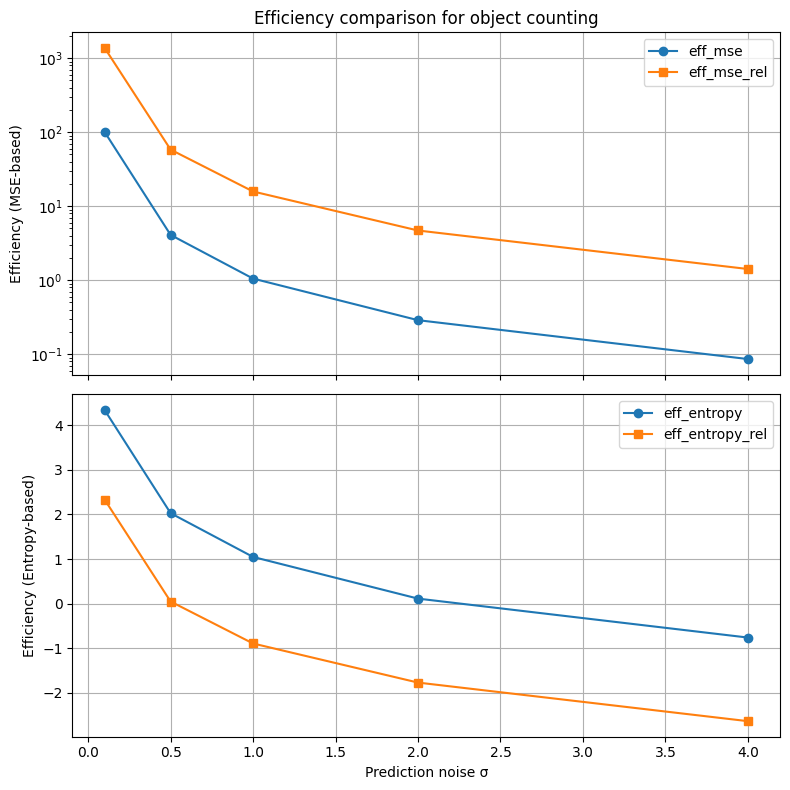

In [21]:
# --- Plot results with separate panels for MSE vs Entropy ---

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Panel 1: MSE-based efficiencies
axes[0].plot(df["sigma"], df["eff_mse"], marker="o", label="eff_mse")
axes[0].plot(df["sigma"], df["eff_mse_rel"], marker="s", label="eff_mse_rel")
axes[0].set_ylabel("Efficiency (MSE-based)")
axes[0].set_yscale("log")
axes[0].set_title("Efficiency comparison for object counting")
axes[0].legend()
axes[0].grid(True)

# Panel 2: Entropy-based efficiencies
axes[1].plot(df["sigma"], df["eff_entropy"], marker="o", label="eff_entropy")
axes[1].plot(df["sigma"], df["eff_entropy_rel"], marker="s", label="eff_entropy_rel")
axes[1].set_xlabel("Prediction noise σ")
axes[1].set_ylabel("Efficiency (Entropy-based)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()